## **EDA**

In [1]:
import pandas as pd
df = pd.read_csv('../data/raw.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


**¿Hay valores nulos?**

No se observan valores nulos en ninguna de las variables

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


**¿Las clases están balanceadas?**

No está balanceado, entre las posibles soluciones:

**1.** Generar datos nuevos con base en la distribución dentro de cada clasificación

**2.** Hacer reclasificación (ej: 3-4 vino malo, 5-6 vino medio, 7-8 vino bueno).

**3.** Hacer una estratificación

La variable quality originalmente contiene múltiples categorías ordinales con una distribución desbalanceada entre clases. Dado que las calificaciones representan una evaluación subjetiva de calidad y que categorías adyacentes tienen interpretaciones similares, se realiza una reclasificación para obtener grupos más representativos, aumentando la cantidad de observaciones por categoría.

In [3]:
df["quality"].value_counts()

quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

**Reclasificación**

bins = [2,4,6,8] define intervalos:

(2,4]

(4,6]

(6,8]

In [23]:
df["quality_label"] = pd.cut(
    df["quality"],
    bins=[2, 4, 6, 8],  # límites
    labels=["malo", "medio", "alto"]
)

Después de la reclasificación, persiste un desbalance entre clases, con predominio de los vinos de calidad media. Se entrenará el modelo con los datos de la reclasificación y utilizando pesos de clase para penalizar en mayor medida los errores sobre las clases minoritarias.


In [5]:
df["quality_label"].value_counts()

quality_label
medio    945
alto     159
malo      39
Name: count, dtype: int64

**¿Hay outliers que representen errores de medición?**

Dado el carácter subjetivo de la variable de calidad, algunos valores considerados atípicos dentro de una clase pueden encontrarse dentro del rango típico de otra categoría, reflejando la superposición existente entre clases.

Sin embargo, se observa una mayor presencia de valores atípicos en distintas variables dentro de la clase media. Por ello, se evaluará inicialmente el modelo de clasificación sin eliminar outliers y posteriormente se comparará con un modelo en el que se eliminen únicamente los valores extremadamente alejados del rango global observado entre todas las clases, y no del rango específico de la clase a la que pertenecen. Esta decisión se toma debido al traslape natural entre categorías.

**¿Hay separabilidad entre las clases?**

Analizando la relación de cada variable con la calidad del vino, se observan algunas variables cuyas medianas y rangos intercuartílicos no presentan cambios significativos entre clases ni una tendencia clara, mostrando una notable superposición. Entre ellas se encuentran residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide y density.

Esto sugiere que dichas variables, consideradas individualmente, no permiten diferenciar claramente la calidad del vino. Sin embargo, podrían aportar información relevante al combinarse con otras variables dentro de un modelo multivariado.

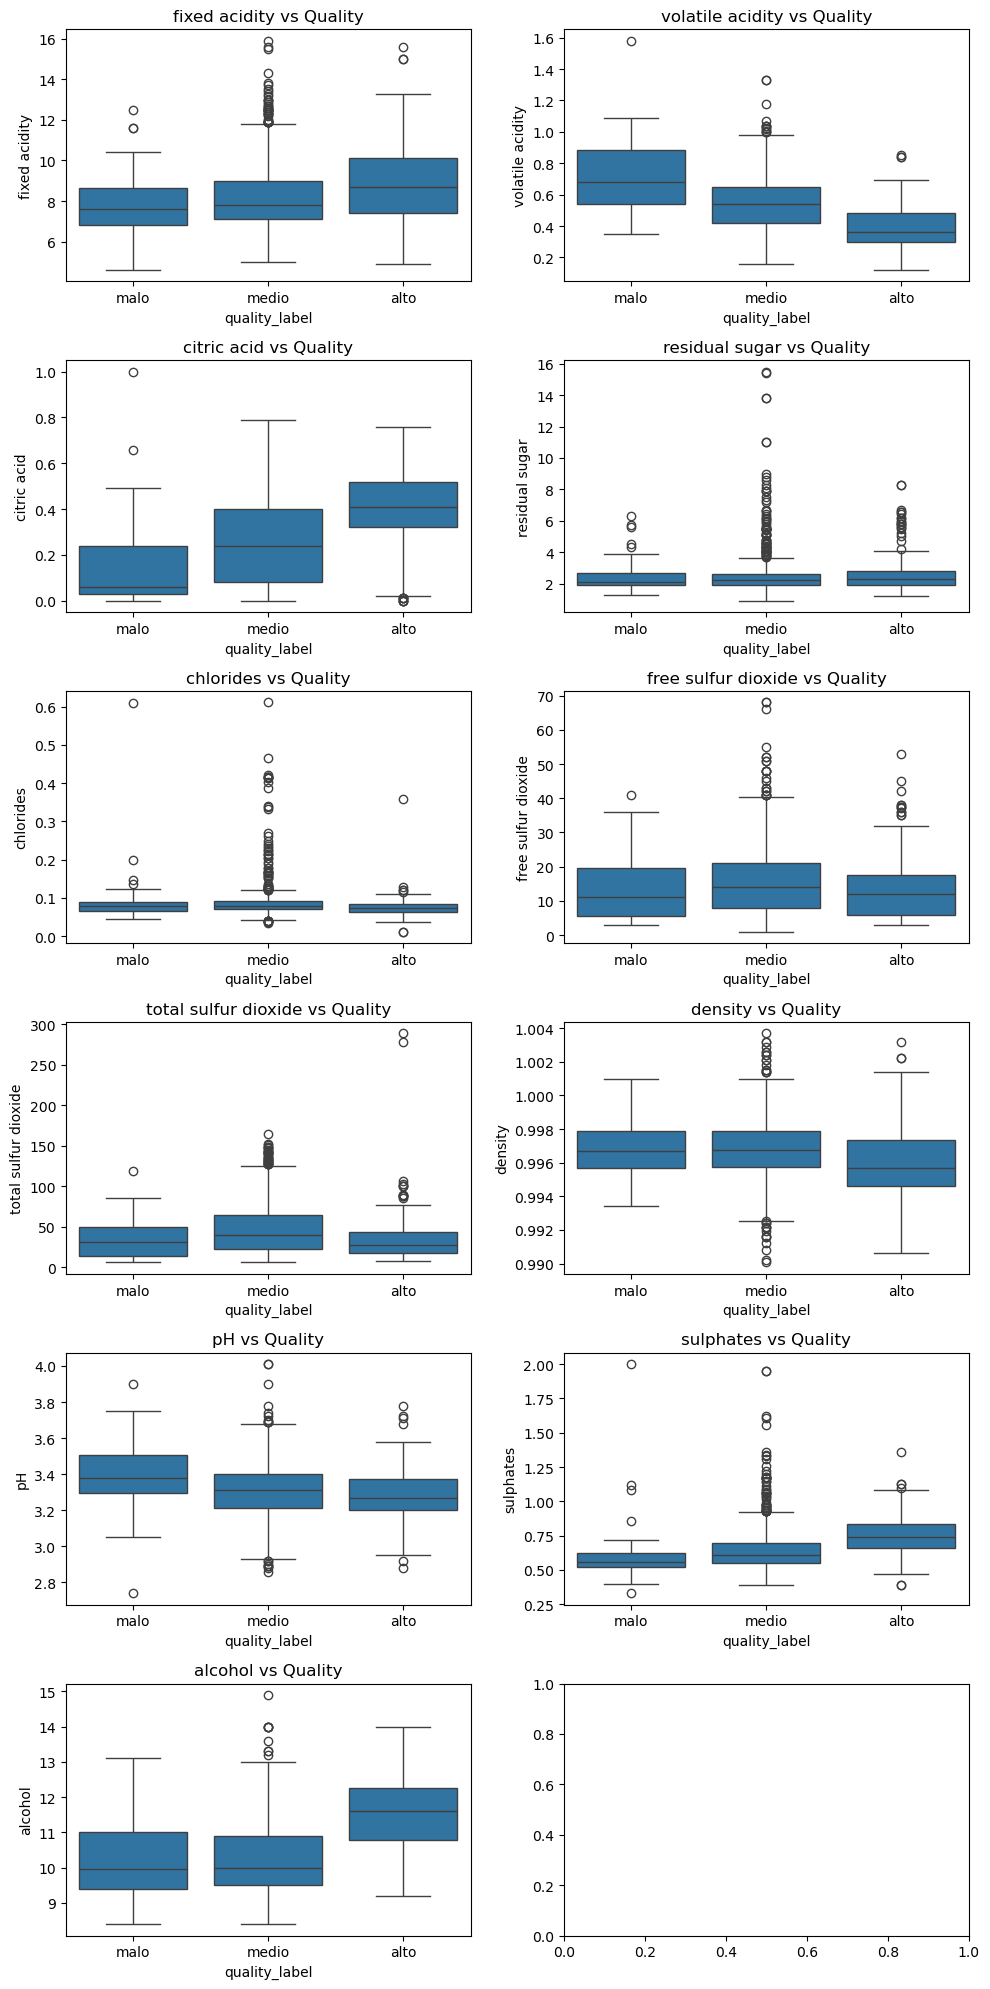

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [col for col in df.columns
        if col not in ["Id", "quality_label", "quality"]]

fig, axes = plt.subplots(6, 2, figsize=(10, 20))

axes = axes.flatten()

for i, col in enumerate(cols):

    sns.boxplot(
        x="quality_label",
        y=col,
        data=df,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} vs Quality")

plt.tight_layout()
plt.show()

Se realizaron diagramas de dispersión con el fin de analizar la separabilidad entre clases considerando simultáneamente dos variables y resaltando posibles interacciones entre ellas, complementando así el análisis univariado previo.

Aunque se seleccionaron variables que individualmente parecían presentar un mayor poder discriminante respecto a las demás, las clases continúan mostrando una considerable superposición y no se observan grupos claramente diferenciados en el espacio bidimensional.

Esto sugiere que la separación entre clases podría depender de combinaciones de mayor dimensionalidad entre múltiples variables y no únicamente de relaciones bidimensionales.


In [7]:
import seaborn as sns
def scatterplot(var1,var2):
  plt.figure(figsize=(5,4))
  sns.scatterplot(
    x=var1,
    y=var2,
    hue="quality_label",
    data=df,
    palette="tab10",
    alpha=0.7
    )
  plt.title(f"{var1} vs {var2} (by Quality)")
  plt.xlabel(f"{var1}")
  plt.ylabel(f"{var2}")
  plt.legend(title="Quality")

  plt.show()



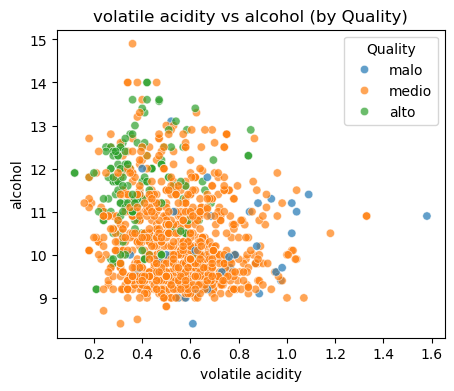

In [8]:
scatterplot("volatile acidity", "alcohol")

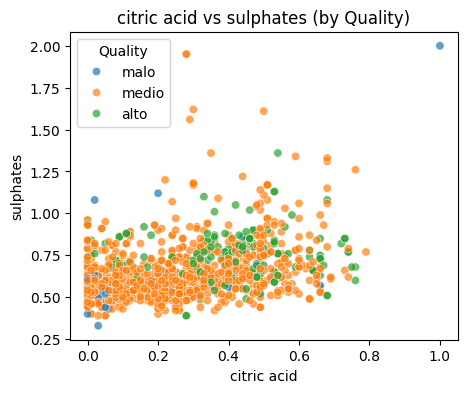

In [53]:
scatterplot("citric acid","sulphates")

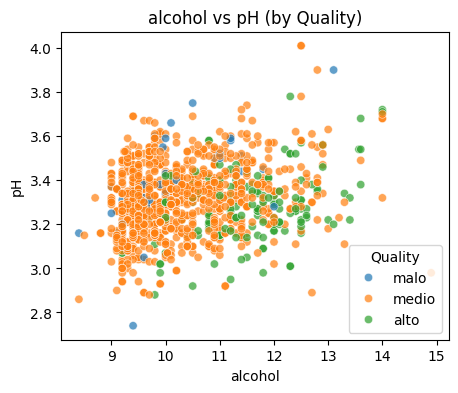

In [54]:
scatterplot("alcohol","pH")

**¿Cuáles son las características que más impactan en la variable objetivo?**

Debido a que el coeficiente de Pearson únicamente mide relaciones lineales entre variables numéricas y no se observaron patrones lineales claros ni separación evidente entre clases en los diagramas de dispersión, se utilizaron diagramas de cajas y bigotes para identificar variables con posibles diferencias entre categorías. Con base en ello, alcohol, sulphates, pH, citric acid, volatile acidity y fixed acidity parecen presentar un mayor poder discriminante. Sin embargo, la utilidad predictiva final dependerá también de la interacción entre variables dentro del modelo.

### **Codificación de la variable dependiente**

In [24]:
df['quality_label'] = df['quality_label'].map({
    'malo': 0,
    'medio': 1,
    'alto': 2
})

In [25]:
df = df.drop(columns= ['Id','quality'])
df.to_csv('../data/processed.csv', index=False)